## Define Trait (Ir)relevant Movie Scenes - Group 2 (Movies 3 & 4)

*This script was used to analyze the data from Group 2 (rated Movie 3 and Movie 4) that was collected through the online study: The first part includes  a) Import of files that were generated as output from Pavlovia.org b) generation of  scene scores from participant’s scene ratings c) computation of neuroticism scores from NEO-FFI responses d) extraction of demographic data and d) compilation of all relevant information into one csv file. The second part includes a) the analysis of sample characteristics (age, gender, and neuroticism scores) and the identification of trait-relevant and trait-irrelevant scenes, along with the generation of the corresponding plots shown in the Supplementary Material.*

#### 1. Read in Data from Excel Sheets (Pavlovia Output) and create one big csv.file with the particpant information

In [1]:
import os
import pandas as pd

print(os.getcwd())
os.chdir(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2")
print(os.getcwd())

C:\Users\jop86ib\Documents\Paper 4\Code
C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2


**IMPORTANT**

*Manually excluded Subject #168795 (Female, 26 y), because they provided identical answers for all questions in the scenes (1 for neg and 5 for pos)*

In [3]:
# Folder with CSV files (Pavlovia Output)
data_folder = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2"

# List for collected data 
all_data = []

# Go through all csv files in the folder
for file in os.listdir(data_folder):
    if file.endswith(".csv"):  # make sure that it is a csv file
        file_path = os.path.join(data_folder, file)
        
        # Read csv file
        df = pd.read_csv(file_path)

        # Extract Subject ID from filename
        subject_id = file.split("_")[0]  # First part of the filename is the Subject ID

        # Compute Neuroticism movie scene ratings
        variable_movie_scenes = df["Movie_scenes"].dropna().reset_index(drop=True)
        frustrated_clean = df["Rating_Question_answer_This scene made me feel frustrated"].dropna().reset_index(drop=True)
        dissatisfied_clean = df["Rating_Question_answer_This scene made me feel dissatisfied with myself"].dropna().reset_index(drop=True)
        tense_clean = df["Rating_Question_answer_This scene made me feel tense"].dropna().reset_index(drop=True)
        confident_clean = df["Rating_Question_answer_This scene made me feel confident in myself and my abilities"].dropna().reset_index(drop=True)
        safe_clean = df["Rating_Question_answer_This scene made me feel safe and secure"].dropna().reset_index(drop=True)
        happy_clean = df["Rating_Question_answer_This scene made me feel happy"].dropna().reset_index(drop=True)

        # Combine variables
        complete_movie_scene_ratings = pd.concat(
            [variable_movie_scenes, frustrated_clean, dissatisfied_clean, tense_clean, confident_clean, safe_clean, happy_clean], 
            axis=1
        )

        # Reverse coding
        reverse_map = {1.0: 5.0, 2.0: 4.0, 3.0: 3.0, 4.0: 2.0, 5.0: 1.0}
        reverse_columns = ["Rating_Question_answer_This scene made me feel confident in myself and my abilities", 
                           "Rating_Question_answer_This scene made me feel safe and secure", 
                           "Rating_Question_answer_This scene made me feel happy"]

        for col in reverse_columns:
            complete_movie_scene_ratings[col + "_reversed"] = complete_movie_scene_ratings[col].replace(reverse_map)

        # Compute sum score
        sum_columns = ["Rating_Question_answer_This scene made me feel frustrated",
                       "Rating_Question_answer_This scene made me feel dissatisfied with myself",
                       "Rating_Question_answer_This scene made me feel tense"] + [col + "_reversed" for col in reverse_columns]

        complete_movie_scene_ratings["Sum_N_score_scene"] = complete_movie_scene_ratings[sum_columns].sum(axis=1)

        # Save individual file with movie scene ratings per subject
        output_folder = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Individual_movie_scene_ratings"
        file_path_individual_scene_ratings = os.path.join(output_folder, f"complete_movie_scene_ratings_subject_{subject_id}.csv")
        complete_movie_scene_ratings.to_csv(file_path_individual_scene_ratings, index=False)

        # Compute the neuroticism score from the NEO_FFI_items
        
        map_normally_coded_items = {"SD": 0, "D": 1, "N": 2, "A": 3, "SA": 4} # Items 6, 11, 21, 26, 36, 41, 51, 56
        map_reverse_coded_items = {"SD": 4, "D": 3, "N": 2, "A": 1, "SA": 0} # Items 1, 16, 31, 46

        normally_coded_items = ["Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.6_I often feel inferior to others.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.11_When I'm under a great deal of stress, sometimes I feel like I am going to pieces.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.21_I often feel tense and jittery.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.26_Sometimes I feel completely worthless.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.36_I often get angry at the way people treat me.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.41_Too often when things go wrong, I get discouraged and feel like giving up.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.51_I often feel helpless and want someone else to solve my problems.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.56_At times I have been so ashamed that I just wanted to hide."]
        reverse_coded_items = ["Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.1_I am not a worrier.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.16_I rarely feel lonely or blue.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.31_I rarely feel fearful or anxious.", "Start_of_study_pavlovia_survey.block_1/NEO_FFI_Questionnaire.46_I am seldom sad or depressed."]

        def recode_value(value, recode_map):
            return recode_map.get(value, None)  # returns none if unknown value

        neuroticism_item_responses = []

        for item in normally_coded_items:
            if item in df.columns:
                recoded_value = recode_value(df[item].iloc[1], map_normally_coded_items)
                if recoded_value is not None:
                    neuroticism_item_responses.append(recoded_value)
                    
        for item in reverse_coded_items:
            if item in df.columns:
                recoded_value = recode_value(df[item].iloc[1], map_reverse_coded_items)
                if recoded_value is not None:
                    neuroticism_item_responses.append(recoded_value)

        sum_N_score_NEO_FFI = sum(neuroticism_item_responses) if neuroticism_item_responses else None  # if values are missing --> none


        
        # Extract demographic data 
        subject_data = {
            "Subject_ID": subject_id,
            "Subject_ID_excel_sheet": df["participant"].iloc[0],
            "User": df["user"].iloc[0],
            "User_ID": df["user_id"].iloc[0],
            "Age": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_age"].iloc[1],
            "Gender": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_gender"].iloc[1],
            "Education": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_highest_level_education"].iloc[1],
            "Years_of_Education": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_years_of_education"].iloc[1],
            "NEO_FFI_N": sum_N_score_NEO_FFI,
            "Occupation": df["Start_of_study_pavlovia_survey.block_1/Demographic_variables_occupation"].iloc[1],
            "Attention_Self_Reflection": df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311]
                if pd.notna(df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311]) and df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[311] != ""
                else df["End_of_study_Pavlovia_survey.block_1/Self_reflection"].iloc[312]            
        }

        # Check whether the subjects wrote something in the textbox
        if "End_of_study_Pavlovia_survey.block_1/Additional Thoughts:" in df.columns:
            thoughts_col = df["End_of_study_Pavlovia_survey.block_1/Additional Thoughts:"]

            if len(thoughts_col) > 312:
              subject_data["Additional_Thoughts"] = thoughts_col.iloc[311] \
                if pd.notna(thoughts_col.iloc[311]) and thoughts_col.iloc[311] != "" \
                else thoughts_col.iloc[312]
            elif len(thoughts_col) > 311:
             subject_data["Additional_Thoughts"] = thoughts_col.iloc[311]
            else:
             subject_data["Additional_Thoughts"] = None  # fallback for short data

        # Save movie scene sum scores as collumns
        for index, row in complete_movie_scene_ratings.iterrows():
            scene_name = row["Movie_scenes"]
            subject_data[scene_name] = row["Sum_N_score_scene"]

        # Save subject data in list
        all_data.append(subject_data)

# Save complete dataset as csv file
final_df = pd.DataFrame(all_data)
final_file_path = r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Combined_data\All_subjects_movie_scenes_group_2_combined.csv"
final_df.to_csv(final_file_path, index=False)

print("Data saved successfully")

Data saved successfully


In [5]:
print(final_df.head)

<bound method NDFrame.head of    Subject_ID  Subject_ID_excel_sheet  \
0      066864                   66864   
1      070008                   70008   
2      094268                   94268   
3      098044                   98044   
4      123861                  123861   
5      134197                  134197   
6      150242                  150242   
7      173613                  173613   
8      193382                  193382   
9      194228                  194228   
10     204168                  204168   
11     230545                  230545   
12     241539                  241539   
13     244327                  244327   
14     256597                  256597   
15     280017                  280017   
16     293931                  293931   
17     338089                  338089   
18     347396                  347396   
19     363477                  363477   
20     366153                  366153   
21     414627                  414627   
22     418061              

### 2. Analyze data

#### 2.1. Sample Characteristics

*Sample Characteristics*

In [7]:
print(os.getcwd())
os.chdir(r"C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Figures")
print(os.getcwd())

C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2
C:\Users\jop86ib\Documents\Paper 4\Empirical Study\Clickworker Group 2\Figures


*Neuroticism Scores*

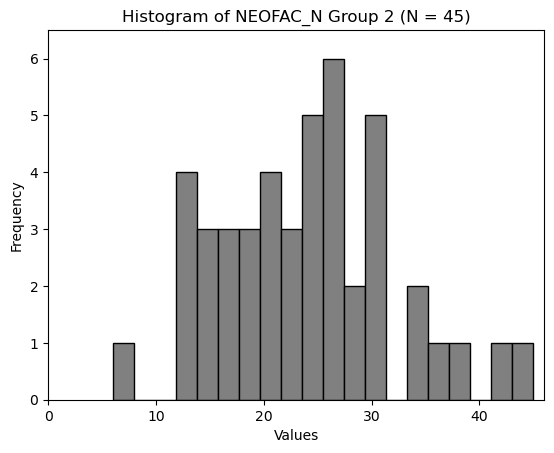

23.933333333333334
8.364970249362951
6
45


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plot histogram of N-scores
plt.hist(final_df['NEO_FFI_N'], bins=20, edgecolor='black', color = 'gray')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of NEOFAC_N Group 2 (N = 45)')

ax = plt.gca()
ax.set_xlim([0, 46])
ax.set_ylim([0, 6.5])

#Save plot 
plt.savefig("Distribution_N_Scores_Group_2.png", dpi=300, bbox_inches="tight") 

# Show the plot
plt.show()

mean_N = final_df['NEO_FFI_N'].mean()
std_N = final_df['NEO_FFI_N'].std()
min_N = final_df['NEO_FFI_N'].min()
max_N = final_df['NEO_FFI_N'].max()

print(mean_N)
print(std_N)
print(min_N)
print(max_N)

*Test Distribution for Normality*

Shapiro-Wilk Test statistic = 0.9848, p-value = 0.8108
Data appears to be normally distributed.


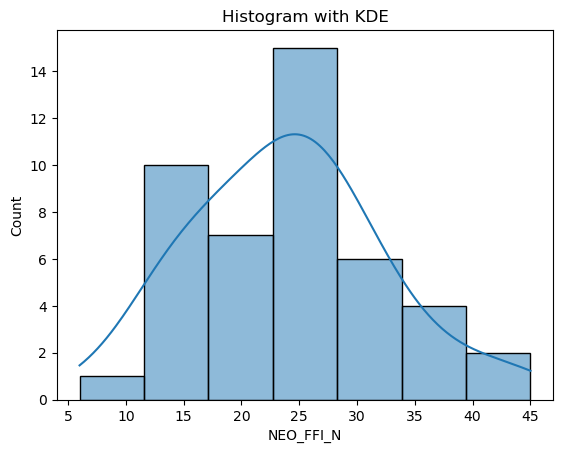

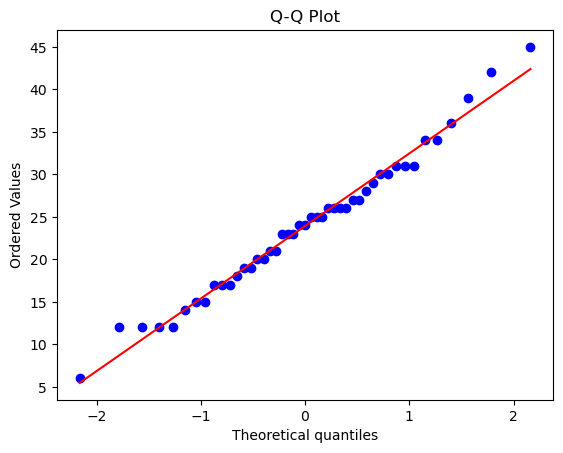

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot

# Shapiro-Wilk Test
neuroticism_scores = final_df['NEO_FFI_N']
stat, p = shapiro(neuroticism_scores)
print(f"Shapiro-Wilk Test statistic = {stat:.4f}, p-value = {p:.4f}")

if p > 0.05:
    print("Data appears to be normally distributed.")
else:
    print("Data does not appear to be normally distributed.")

# Visualizations
sns.histplot(neuroticism_scores, kde=True)
plt.title('Histogram with KDE')
plt.show()

probplot(neuroticism_scores, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

*Age and Gender*

In [136]:
mean_age = final_df['Age'].mean()
std_age = final_df['Age'].std()
max_age = final_df['Age'].max()
min_age = final_df['Age'].min()

print(mean_age)
print(std_age)
print(max_age)
print(min_age)

gender_counts = final_df['Gender'].value_counts()

print(f"Number of males (M): {gender_counts.get('Male', 0)}")
print(f"number of females (F): {gender_counts.get('Female', 0)}")
print(f"number of diverse (D): {gender_counts.get('Diverse', 0)}")

meanN_group_2 = final_df['NEO_FFI_N'].mean()
print(meanN_group_2)

30.355555555555554
4.07406183040707
36.0
22.0
Number of males (M): 20
number of females (F): 25
number of diverse (D): 0
23.933333333333334


*Correlation between mean across all scene ratings and neuroticism score*

In [22]:
from scipy.stats import pearsonr

filtered_columns = [col for col in final_df.columns if col.startswith("Scenes_Movie_")]
subject_specific_average_scene_score = final_df[filtered_columns].mean(axis=1)
print(subject_specific_average_scene_score.size)

# Copmute Pearson correlation
r_value, p_value = pearsonr(subject_specific_average_scene_score, final_df['NEO_FFI_N'])
print(f"Pearson correlation: r = {r_value:.3f}, p = {p_value:.4f}")

45
Pearson correlation: r = 0.298, p = 0.0469


#### 2.2. Scene Scores

*Plot the distribution of scene ratings*

**RAW SCORES** --> not uswed in the paper 

*Take mean over raw scores*

                               Column  Mean Value
0    Scenes_Movie_3_clean/scene_1.mp4   15.133333
1    Scenes_Movie_3_clean/scene_2.mp4   19.400000
2    Scenes_Movie_3_clean/scene_3.mp4   18.422222
3    Scenes_Movie_3_clean/scene_4.mp4   14.000000
4    Scenes_Movie_3_clean/scene_5.mp4   19.377778
5    Scenes_Movie_3_clean/scene_6.mp4   19.555556
6    Scenes_Movie_3_clean/scene_7.mp4   19.333333
7    Scenes_Movie_3_clean/scene_8.mp4   16.933333
8    Scenes_Movie_3_clean/scene_9.mp4   15.022222
9   Scenes_Movie_3_clean/scene_10.mp4   12.555556
10  Scenes_Movie_3_clean/scene_11.mp4   12.377778
11  Scenes_Movie_3_clean/scene_12.mp4   12.377778
12  Scenes_Movie_3_clean/scene_13.mp4   12.466667
13  Scenes_Movie_3_clean/scene_14.mp4   12.377778
14  Scenes_Movie_3_clean/scene_15.mp4   11.111111
15  Scenes_Movie_3_clean/scene_16.mp4   19.400000
16  Scenes_Movie_3_clean/scene_17.mp4   20.111111
17  Scenes_Movie_3_clean/scene_18.mp4   20.222222
18  Scenes_Movie_3_clean/scene_19.mp4   21.155556


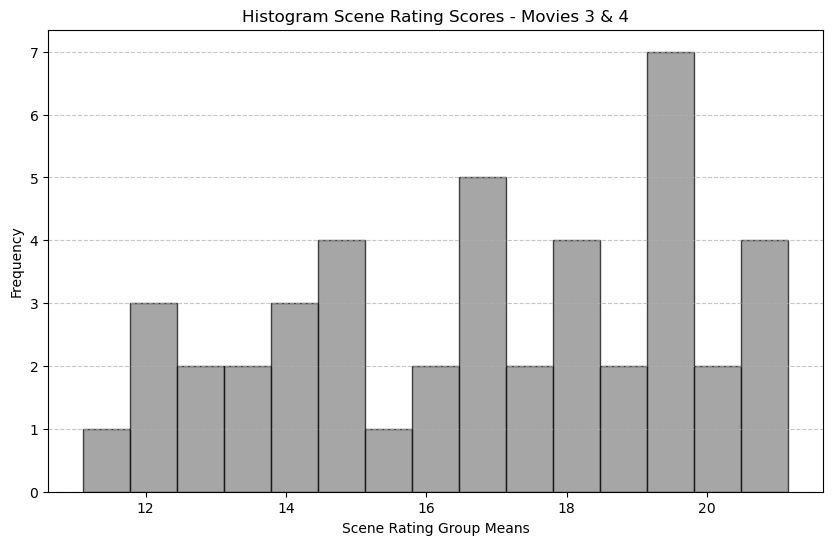

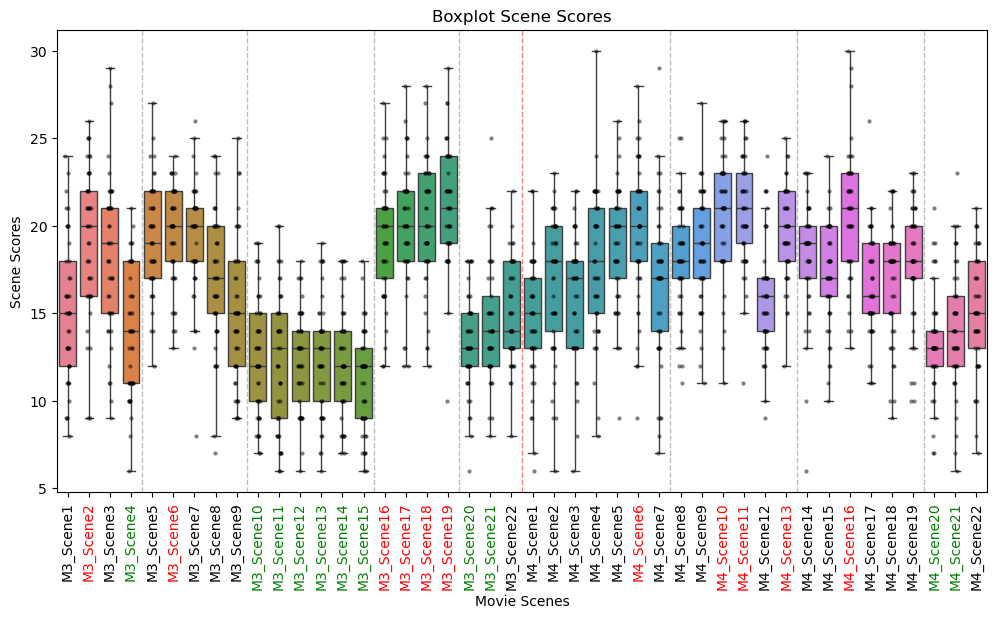

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select all columns starting with "Scenes_Movie":
filtered_columns = [col for col in final_df.columns if col.startswith("Scenes_Movie_")]

# Compute average values per column
mean_values = final_df[filtered_columns].mean()

# Print the mean values with column names
mean_df = pd.DataFrame({"Column": mean_values.index, "Mean Value": mean_values.values})
print(mean_df)

# Get descripives of scene ratings
print("Mean of all scene average scores:", mean_values.values.mean())
print("Standard deviation of scene average scores:", mean_values.values.std())
print("Minimum scene average score:", mean_values.values.min())
print("Maximum scene average score:", mean_values.values.max())

# Get 11 lowest and 11 highest mean values (equals 25%)
lowest_11 = mean_df.nsmallest(11, "Mean Value")
highest_11 = mean_df.nlargest(11, "Mean Value")

# Print results
print("11 Lowest Mean Values:")
print(lowest_11)
print("\n11 Highest Mean Values:")
print(highest_11)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(mean_values, bins=15, edgecolor="black", color="gray", alpha=0.7)

plt.xlabel("Scene Rating Group Means")
plt.ylabel("Frequency")
plt.title("Histogram Scene Rating Scores - Movies 3 & 4")
plt.grid(axis="y", linestyle="--", alpha=0.7)

#Save plot 
plt.savefig("Distribution_Scene_Rating_Scores_Group_2.png", dpi=300, bbox_inches="tight")

plt.show()

# Adjust scene labels  
new_labels = ["M3_Scene1", "M3_Scene2", "M3_Scene3", "M3_Scene4", "M3_Scene5", "M3_Scene6", "M3_Scene7", "M3_Scene8", "M3_Scene9",  "M3_Scene10", "M3_Scene11", "M3_Scene12", "M3_Scene13", "M3_Scene14", "M3_Scene15", "M3_Scene16", "M3_Scene17", "M3_Scene18", "M3_Scene19", "M3_Scene20", "M3_Scene21", "M3_Scene22", "M4_Scene1", "M4_Scene2", "M4_Scene3", "M4_Scene4", "M4_Scene5","M4_Scene6", "M4_Scene7", "M4_Scene8", "M4_Scene9",  "M4_Scene10", "M4_Scene11", "M4_Scene12", "M4_Scene13", "M4_Scene14", "M4_Scene15", "M4_Scene16", "M4_Scene17", "M4_Scene18", "M4_Scene19", "M4_Scene20", "M4_Scene21", "M4_Scene22"]

#Boxplot with individual scores 

plt.figure(figsize=(12, 6))
sns.boxplot(data=final_df[filtered_columns], showfliers=False)
sns.stripplot(data=final_df[filtered_columns], size=3, color="black", alpha=0.5, jitter=True)

_, ticks_objs = plt.xticks(ticks=range(len(filtered_columns)), labels=new_labels, rotation=90)

# Set label color according to trait-relevance/trait-irrelevance

for i in [3,9,10,11,12,13,14,19,20,41,42]: #TIR scenes --> green
    ticks_objs[i].set_color('green')

for j in [1,5,15,16,17,18,27,31,32,34,37]: #TR scenes --> red
    ticks_objs[j].set_color('red')

plt.xlabel("Movie Scenes")
plt.ylabel("Scene Scores")
plt.title("Boxplot Scene Scores")

line_positions = [3.5, 8.5, 14.5, 18.5, 21.5, 28.5, 34.5, 40.5]

# Insert dashed lines to separate between scenes
for pos in line_positions:
    color = "red" if pos == 21.5 else "gray"
    plt.axvline(x=pos, color=color, linestyle="dashed", linewidth=1, alpha=0.5)

#Save plot 
plt.savefig("Boxplot_Scene_Rating_Scores_Group_2_mark_scenes.png", dpi=300, bbox_inches="tight")

plt.show()

**SCALED SCORES** --> used in the paper

*Take mean across scaled scores*

                               Column  Mean Value
0    Scenes_Movie_3_clean/scene_1.mp4    3.910679
1    Scenes_Movie_3_clean/scene_2.mp4    6.868734
2    Scenes_Movie_3_clean/scene_3.mp4    6.097811
3    Scenes_Movie_3_clean/scene_4.mp4    3.171412
4    Scenes_Movie_3_clean/scene_5.mp4    6.896319
5    Scenes_Movie_3_clean/scene_6.mp4    7.019153
6    Scenes_Movie_3_clean/scene_7.mp4    6.744889
7    Scenes_Movie_3_clean/scene_8.mp4    5.308710
8    Scenes_Movie_3_clean/scene_9.mp4    3.959052
9   Scenes_Movie_3_clean/scene_10.mp4    2.325348
10  Scenes_Movie_3_clean/scene_11.mp4    2.373083
11  Scenes_Movie_3_clean/scene_12.mp4    2.211276
12  Scenes_Movie_3_clean/scene_13.mp4    2.299234
13  Scenes_Movie_3_clean/scene_14.mp4    2.203903
14  Scenes_Movie_3_clean/scene_15.mp4    1.283682
15  Scenes_Movie_3_clean/scene_16.mp4    6.714512
16  Scenes_Movie_3_clean/scene_17.mp4    7.255387
17  Scenes_Movie_3_clean/scene_18.mp4    7.400444
18  Scenes_Movie_3_clean/scene_19.mp4    7.932598


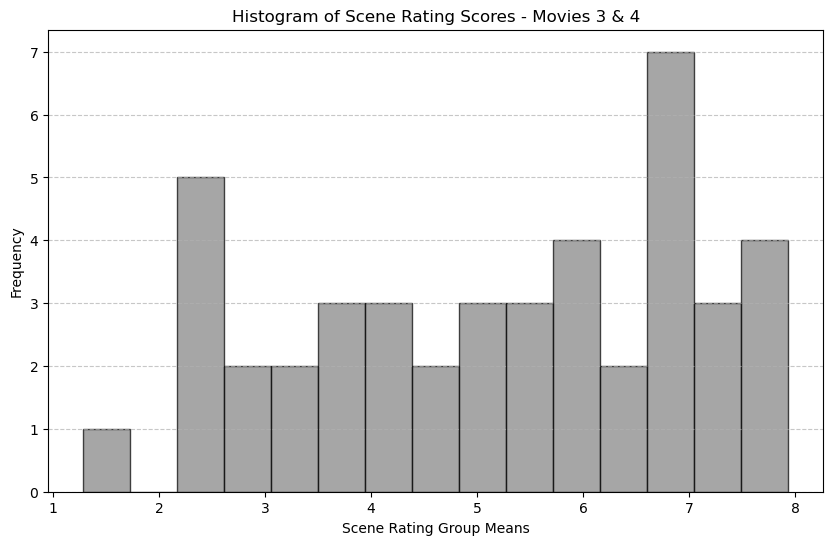

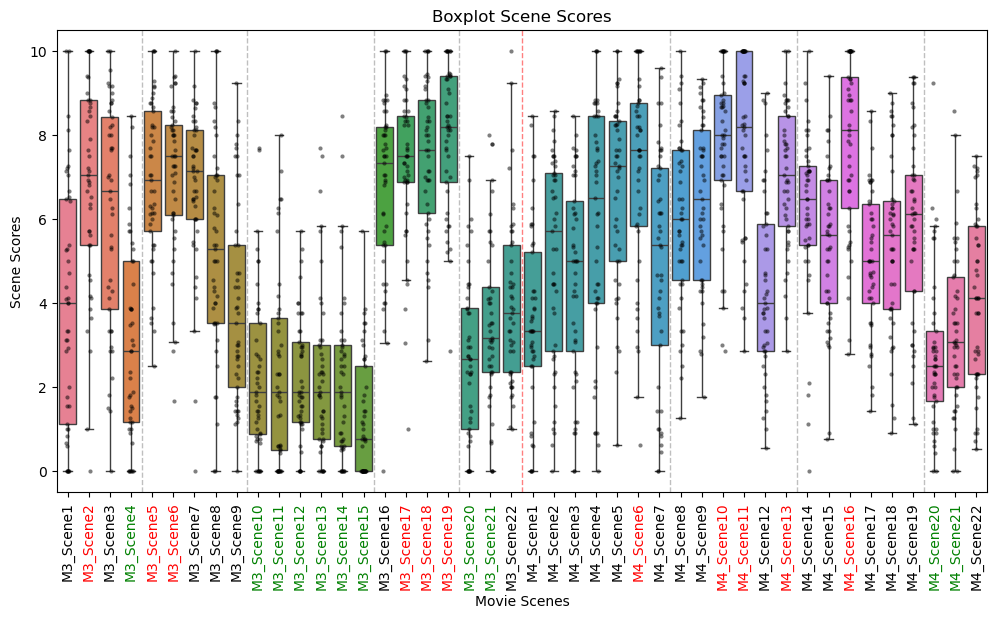

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Select columns that start with "Scenes_Movie_"
filtered_columns = [col for col in final_df.columns if col.startswith("Scenes_Movie_")]

# Subset the dataframe with the relevant columns
df_filtered = final_df[filtered_columns]

# Min-Max scaling for each row (from 0 to 10)
df_scaled = df_filtered.apply(lambda row: 10 * (row - row.min()) / (row.max() - row.min()) if row.max() != row.min() else 0, axis=1)

# Calculate mean values per column
mean_values = df_scaled.mean()

# Print the mean values with column names
mean_df = pd.DataFrame({"Column": mean_values.index, "Mean Value": mean_values.values})
print(mean_df)

# Get 11 lowest and 11 highest mean values (equals 25%)
lowest_11 = mean_df.nsmallest(11, "Mean Value")
highest_11 = mean_df.nlargest(11, "Mean Value")

# Print results
print("11 Lowest Mean Values:")
print(lowest_11)
print("\n11 Highest Mean Values:")
print(highest_11)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(mean_values, bins=15, edgecolor="black", color = "gray", alpha=0.7)

plt.xlabel("Scene Rating Group Means")
plt.ylabel("Frequency")
plt.title("Histogram of Scene Rating Scores - Movies 3 & 4")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# Adjust scene labels  
new_labels = ["M3_Scene1", "M3_Scene2", "M3_Scene3", "M3_Scene4", "M3_Scene5","M3_Scene6", "M3_Scene7", "M3_Scene8", "M3_Scene9",  "M3_Scene10", "M3_Scene11", "M3_Scene12", "M3_Scene13", "M3_Scene14", "M3_Scene15", "M3_Scene16", "M3_Scene17", "M3_Scene18", "M3_Scene19", "M3_Scene20", "M3_Scene21", "M3_Scene22", "M4_Scene1", "M4_Scene2", "M4_Scene3", "M4_Scene4", "M4_Scene5","M4_Scene6", "M4_Scene7", "M4_Scene8", "M4_Scene9",  "M4_Scene10", "M4_Scene11", "M4_Scene12", "M4_Scene13", "M4_Scene14", "M4_Scene15", "M4_Scene16", "M4_Scene17", "M4_Scene18", "M4_Scene19", "M4_Scene20", "M4_Scene21", "M4_Scene22"]

#Boxplot with individual scores 

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, showfliers=False)
sns.stripplot(data=df_scaled, size=3, color="black", alpha=0.5, jitter=True)


_, ticks_objs = plt.xticks(ticks=range(len(filtered_columns)), labels=new_labels, rotation=90)

# Set label color according to trait-relevance/trait-irrelevance

for i in [3,9,10,11,12,13,14,19,20,41,42]: #TIR scenes --> green
    ticks_objs[i].set_color('green')

for j in [1,4,5,16,17,18,27,31,32,34,37]: #TR scenes --> red
    ticks_objs[j].set_color('red')


plt.xlabel("Movie Scenes")
plt.ylabel("Scene Scores")
plt.title("Boxplot Scene Scores")

line_positions = [3.5, 8.5, 14.5, 18.5, 21.5, 28.5, 34.5, 40.5]

# Insert dashed lines to separate between scenes
for pos in line_positions:
    color = "red" if pos == 21.5 else "gray"
    plt.axvline(x=pos, color=color, linestyle="dashed", linewidth=1, alpha=0.5)

#Save plot 
plt.savefig("Boxplot_Scene_Rating_Scores_Scaled_Group_2_mark_scenes.png", dpi=300, bbox_inches="tight")


plt.show()